**Task 2: Quantitative analysis using pynance and TaLib**

Objective: Load historical stock price data, compute financial technical indicators, and
visualize the results to understand market behavior.


In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))

1. Prepare Your Data


In [2]:
# Import your custom modules
from src.data_loader import load_stock_data, process_financial_data

# Define file path
aapl_path = "../data/raw/aapl.csv"

# Load raw dataset
print("Loading raw data for aapl...")
raw_aapl = load_stock_data(aapl_path)

# Clean dataset
print("Applying financial cleaning rules...")
clean_aapl = process_financial_data(raw_aapl)


# Check data types
print(clean_aapl.dtypes)

# Missing values
print("Missing Values Remaining")
print(clean_aapl.isnull().sum())

# Preview dataset
print("Preview of the Clean aapl Dataset")
print(clean_aapl.head())

Loading raw data for aapl...
Applying financial cleaning rules...
Date      datetime64[us, UTC]
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
dtype: object
Missing Values Remaining
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Preview of the Clean aapl Dataset
                       Date     Close      High       Low      Open  \
0 2009-01-02 00:00:00+00:00  2.721686  2.730385  2.554037  2.575630   
1 2009-01-05 00:00:00+00:00  2.836553  2.884539  2.780469  2.794266   
2 2009-01-06 00:00:00+00:00  2.789767  2.914229  2.770872  2.877641   
3 2009-01-07 00:00:00+00:00  2.729484  2.774170  2.706990  2.753477   
4 2009-01-08 00:00:00+00:00  2.780169  2.793666  2.700393  2.712090   

       Volume  
0   746015200  
1  1181608400  
2  1289310400  
3   753048800  
4   673500800  


**2. Compute Technical Indicators with TA-Lib**

In [3]:
from src.indicators import add_moving_averages, add_rsi, add_macd, add_financial_metrics

print("Computing technical indicators for aapl...")

# Apply the mathematical transformations sequentially
clean_aapl = add_moving_averages(clean_aapl)
clean_aapl = add_rsi(clean_aapl)
clean_aapl = add_macd(clean_aapl)

# Apply the financial metrics (This creates the 'Daily_Return' column!)
clean_aapl = add_financial_metrics(clean_aapl)

print(" Indicators computed successfully! Previewing results:")
clean_aapl[
    [
        'Date', 
        'Close', 
        'SMA_20', 
        'RSI', 
        'MACD', 
        'Daily_Return'
    ]
].tail()

2026-05-10 09:38:58,754 - WARNING - PyNance calculation skipped: module 'pynance' has no attribute 'tech'


Computing technical indicators for aapl...
 Indicators computed successfully! Previewing results:


,Date,Close,SMA_20,RSI,MACD,Daily_Return
3769,2023-12-22 00:00:00+00:00,191.788757,191.856618,54.672784,2.633141,-0.005548
3770,2023-12-26 00:00:00+00:00,191.243912,192.018094,53.090049,2.304751,-0.002841
3771,2023-12-27 00:00:00+00:00,191.342972,192.154308,53.354446,2.029104,0.000518
3772,2023-12-28 00:00:00+00:00,191.768951,192.362839,54.540999,1.823998,0.002226
3773,2023-12-29 00:00:00+00:00,190.728775,192.490633,51.121347,1.559539,-0.005424


**Apply PyNance for Financial Metrics**

In [4]:
from src.financial_metrics import add_financial_metrics

clean_aapl = add_financial_metrics(clean_aapl)

# Pass the analyzed_aapl dataframe you generated in the previous step
clean_aapl = add_financial_metrics(clean_aapl)
print("Metrics computed successfully!")
clean_aapl[['Date', 'Returns', 'Volatility_20', 'Cumulative_Return']].tail()

Metrics computed successfully!


,Date,Returns,Volatility_20,Cumulative_Return
3769,2023-12-22 00:00:00+00:00,-0.005548,0.009071,70.466884
3770,2023-12-26 00:00:00+00:00,-0.002841,0.009103,70.266697
3771,2023-12-27 00:00:00+00:00,0.000518,0.009086,70.303094
3772,2023-12-28 00:00:00+00:00,0.002226,0.008973,70.459607
3773,2023-12-29 00:00:00+00:00,-0.005424,0.009078,70.077426


**Visualize the Data**


Generating Price & Moving Averages Chart...


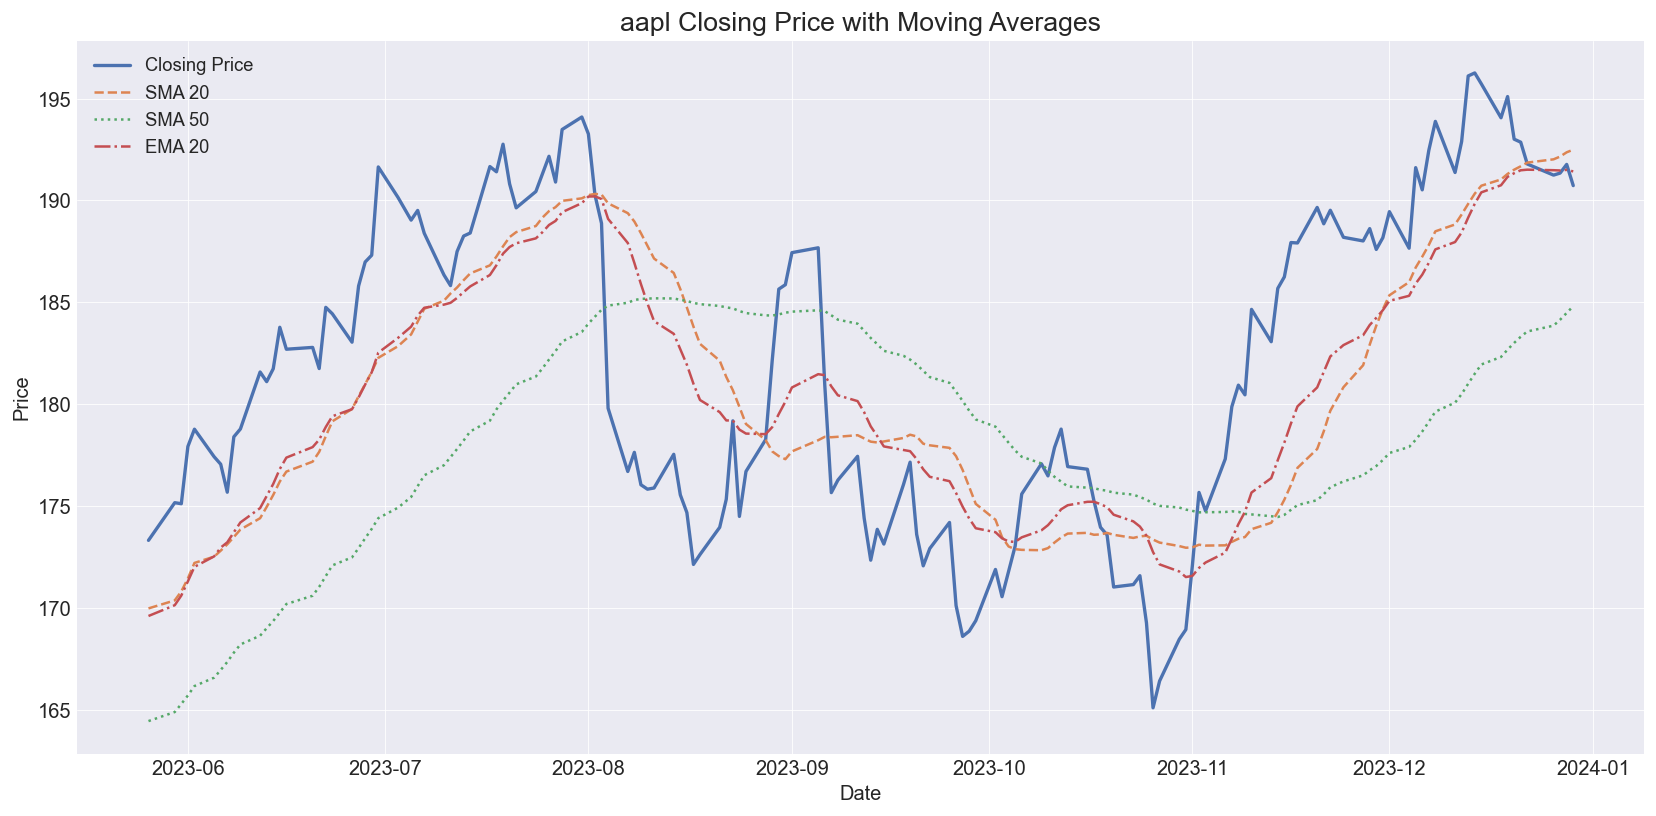

In [5]:
from src.visuals import set_visual_style, plot_price_and_ma, plot_rsi, plot_macd

# Apply the global darkgrid style
set_visual_style()

symbol = 'aapl'

# 1. Plot Price and Moving Averages
print("Generating Price & Moving Averages Chart...")
plot_price_and_ma(clean_aapl, symbol)

Generating RSI Chart...


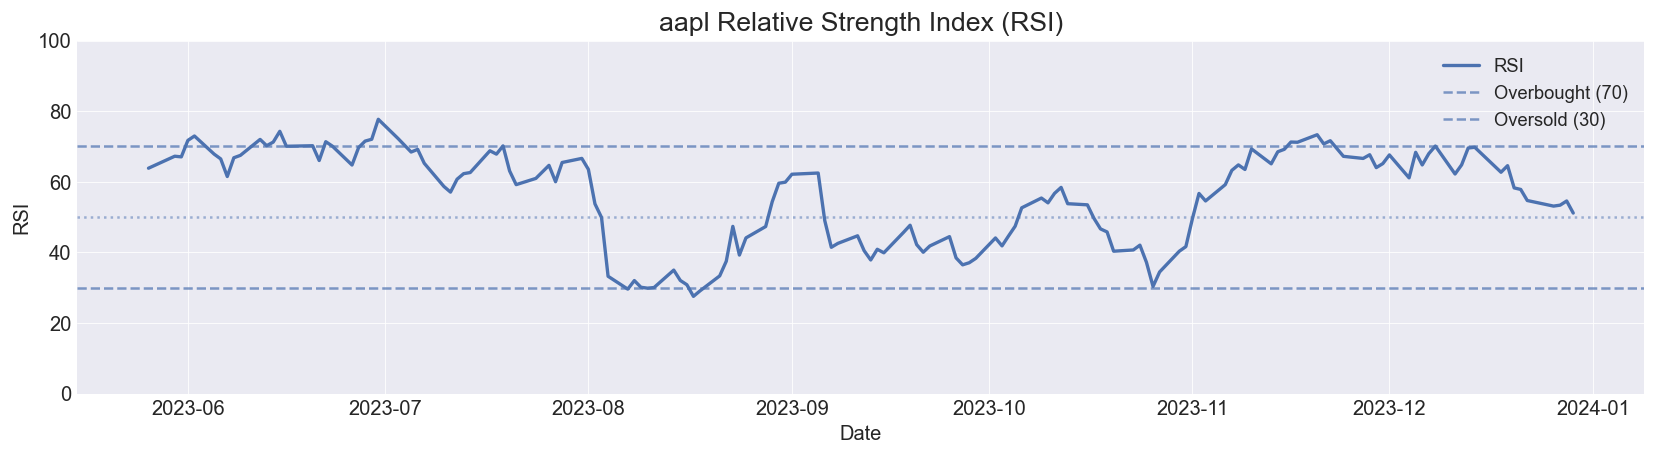

In [6]:
# 2. Plot Relative Strength Index
print("Generating RSI Chart...")
plot_rsi(clean_aapl, symbol)

Generating MACD Chart...


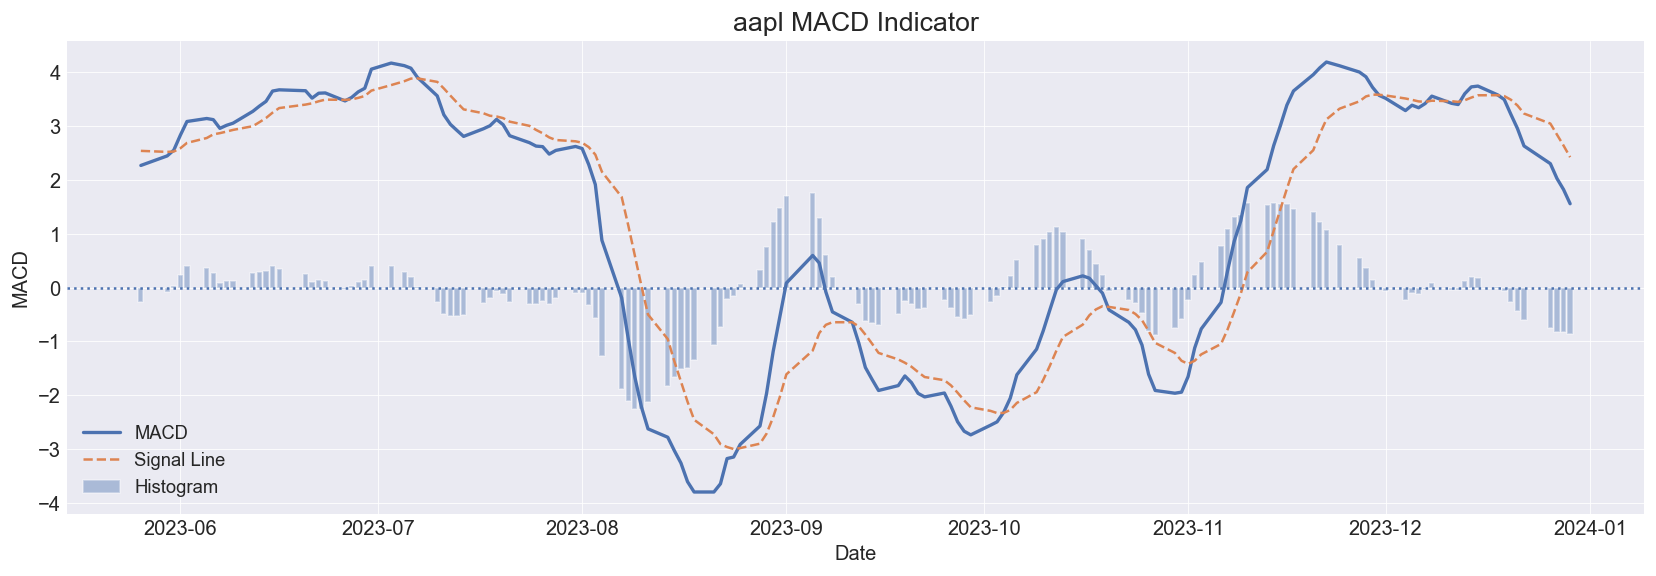

In [7]:
# 3. Plot MACD
print("Generating MACD Chart...")
plot_macd(clean_aapl, symbol)

In [8]:
# save the processed dataset for task 3
import os

# Ensure the directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save the finalized dataset
processed_aapl_path = f"../data/processed/{symbol}_processed.csv"
clean_aapl.to_csv(processed_aapl_path, index=False)

print(f" {symbol} quantitative analysis complete and saved to {processed_aapl_path}")

 aapl quantitative analysis complete and saved to ../data/processed/aapl_processed.csv
